# TAHAPAN PRA-PEMROSESAN DATA, VALIDASI, DAN REKAYASA FITUR MULTIDIMENSI
**Sertifikasi Data Scientist — Portofolio Kelayakan**

**Dokumen**: Notebook 02 - Data Preparation, Validation, Cleansing, Feature Engineering, & SMOTE

**Unit Kompetensi Tercakup**:
* J.62DMI00.006.1 (Memvalidasi Data)
* J.62DMI00.008.1 (Membersihkan Data)
* J.62DMI00.009.1 (Mengkonstruksi Data)

---

## 1. Landasan Teoretis & Pemetaan Solusi
Tahap pra-pemrosesan ini bertindak sebagai jembatan kritis antara data mentah (*raw elements*) dan algoritma matematis. Seluruh langkah yang dieksekusi dalam dokumen ini merupakan solusi teknis langsung atas temuan anomali pada fase *Exploratory Data Analysis* (Notebook 01).

### 1.1 Rekonsiliasi Temuan Bisnis (NB 01) ke Eksekusi Teknis (NB 02)
1. **Temuan:** Sandi Abstrak Tidak Terbaca (Kode `A11`, `A34`, dll). 
   * **Solusi (Unit 8):** Implementasi pemetaan kamus (*Dictionary Mapping*) untuk mengonversi sandi abstrak menjadi nomenklatur industri agar interpretasi bisnis (XAI) dapat dilakukan di akhir fase.
2. **Temuan:** Disparitas Magnitudo (Nilai kredit puluhan ribu vs Usia puluhan).
   * **Solusi (Unit 9):** Eksekusi standardisasi varians (*StandardScaler/Z-Score*) pada fitur numerik untuk memitigasi distorsi bobot pada algoritma linier/berbasis jarak.
3. **Temuan:** Asimetri Kelas Target (Rasio Lancar:Macet = 70:30).
   * **Solusi (Unit 9):** Sintesis kelas minoritas menggunakan *Synthetic Minority Over-sampling Technique* (SMOTE) untuk mencapai ekuilibrium (50:50) guna mencegah model terbias pada kelas mayoritas.

### 1.2 Pencegahan Kebocoran Data (Data Leakage Prevention)
**Rasionalisasi Metodologis:**
Sebuah kesalahan fatal dalam pemodelan prediktif adalah melakukan penskalaan dan penyeimbangan kelas (*SMOTE*) pada **seluruh dataset** sebelum pemisahan data (*Train-Test Split*). Secara metodologis, tindakan tersebut membocorkan informasi varians dari set uji (*test set*) ke dalam set latih (*training set*). 

**Arsitektur Pipeline:** Pemisahan Data (`Split`) $\rightarrow$ Penskalaan (`Fit & Transform` pada Train, `Transform Only` pada Test) $\rightarrow$ Sintesis Data (`SMOTE` eksklusif hanya pada subset Train).

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Mengamankan reproduksibilitas komputasi
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Mendefinisikan nama kolom sesuai standardisasi Notebook 01
columns = [
    'checking_account_status', 'duration_months', 'credit_history', 'purpose', 
    'credit_amount', 'savings_account_status', 'employment_duration', 
    'installment_rate', 'personal_status_sex', 'other_debtors_guarantors', 
    'present_residence_since', 'property', 'age_years', 'other_installment_plans', 
    'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 
    'target_risk'
]

# Ambil data mentah (Robust Pathing check)
path_1 = '../data/raw/german.data'
path_2 = 'data/raw/german.data'
DATA_PATH = path_1 if os.path.exists(path_1) else path_2

df = pd.read_csv(DATA_PATH, sep=' ', header=None, names=columns)
df['target_risk'] = df['target_risk'].map({1: 0, 2: 1})

print(f"Data Berhasil Dimuat. Ukuran awal: {df.shape}")

Data Berhasil Dimuat. Ukuran awal: (1000, 21)


## 2. Validasi Struktur, Duplikasi, dan Konsistensi Objek Data
**[SKKNI: J.62DMI00.006.1 - Memvalidasi Data]**

Prosedur ini dijalankan untuk melakukan audit programmatik terhadap integritas data latih sebelum rekayasa fitur. Validasi difokuskan pada empat parameter utama:
1. *Missing Value Operational Check* (Memastikan tidak ada data yang hilang di tengah jalan).
2. *Duplicate Records Audit* (Mendeteksi dan mereduksi redundansi data observasi).
3. *Domain Range Constraints validation* (Memastikan kepatuhan logika finansial pada batas usia, tenor, dan nominal).
4. *Target Variable Integrity* (Memastikan kelas target steril dari kontaminasi nilai di luar biner).

In [2]:
import pandas as pd
from IPython.display import display, HTML

"""
Modul Validasi Integritas Data (Audit Programmatik).
Mengeksekusi pengecekan missing values, duplikasi, dan batasan finansial,
lalu menyajikannya dalam bentuk Tabel Scorecard Visual.
"""

validation_passed = True
audit_log = [] # List untuk menyimpan hasil audit menjadi tabel

# 2.1 Pengecekan Missing Values secara Eksplisit
missing_summary = df.isnull().sum().sum()
if missing_summary == 0:
    audit_log.append({"Parameter Audit": "Ketiadaan Data (Missing Values)", "Status": "PASSED", "Detail Keterangan": "100% data terisi (0 sel kosong)"})
else:
    audit_log.append({"Parameter Audit": "Ketiadaan Data (Missing Values)", "Status": "FAILED", "Detail Keterangan": f"Terdeteksi {missing_summary} sel kosong!"})
    validation_passed = False

# 2.2 Pengecekan Data Duplikat
duplicate_count = df.duplicated().sum()
if duplicate_count == 0:
    audit_log.append({"Parameter Audit": "Duplikasi Observasi (Redundancy)", "Status": "PASSED", "Detail Keterangan": "Tidak ada baris duplikat"})
else:
    df = df.drop_duplicates()
    audit_log.append({"Parameter Audit": "Duplikasi Observasi (Redundancy)", "Status": "MITIGATED", "Detail Keterangan": f"{duplicate_count} baris duplikat dihapus"})

# 2.3 Validasi Range Constraints Finansial & Demografi
invalid_age = len(df[df['age_years'] < 18])
invalid_duration = len(df[df['duration_months'] <= 0])
invalid_amount = len(df[df['credit_amount'] <= 0])

if invalid_age == 0:
    audit_log.append({"Parameter Audit": "Batasan Aturan Usia (>= 18)", "Status": "PASSED", "Detail Keterangan": "Seluruh usia nasabah legal"})
else:
    audit_log.append({"Parameter Audit": "Batasan Aturan Usia (>= 18)", "Status": "FAILED", "Detail Keterangan": f"{invalid_age} nasabah di bawah umur"})
    validation_passed = False

if invalid_duration == 0 and invalid_amount == 0:
    audit_log.append({"Parameter Audit": "Batasan Logika Finansial (> 0)", "Status": "PASSED", "Detail Keterangan": "Tenor dan Nominal bernilai positif"})
else:
    audit_log.append({"Parameter Audit": "Batasan Logika Finansial (> 0)", "Status": "FAILED", "Detail Keterangan": f"Tenor invalid: {invalid_duration}, Nominal invalid: {invalid_amount}"})
    validation_passed = False

# 2.4 Validasi Kelas Target
unique_targets = df['target_risk'].unique()
if set(unique_targets) == {0, 1}:
    audit_log.append({"Parameter Audit": "Integritas Variabel Target (Biner)", "Status": "PASSED", "Detail Keterangan": "Steril (Hanya berisi 0 dan 1)"})
else:
    audit_log.append({"Parameter Audit": "Integritas Variabel Target (Biner)", "Status": "FAILED", "Detail Keterangan": f"Terdeteksi label ilegal: {unique_targets}"})
    validation_passed = False

audit_df = pd.DataFrame(audit_log)

# Menambahkan judul HTML agar lebih rapi di Jupyter
display(HTML("<h3>Scorecard Audit Validasi Integritas Data</h3>"))
display(audit_df)

print(f"STATUS AKHIR KELAYAKAN DATA INPUT : {validation_passed}")

,Parameter Audit,Status,Detail Keterangan
0,Ketiadaan Data (Missing Values),PASSED,100% data terisi (0 sel kosong)
1,Duplikasi Observasi (Redundancy),PASSED,Tidak ada baris duplikat
2,Batasan Aturan Usia (>= 18),PASSED,Seluruh usia nasabah legal
3,Batasan Logika Finansial (> 0),PASSED,Tenor dan Nominal bernilai positif
4,Integritas Variabel Target (Biner),PASSED,Steril (Hanya berisi 0 dan 1)


STATUS AKHIR KELAYAKAN DATA INPUT : True


### 2.5 Rekomendasi Hasil Penilaian Kualitas dan Kecukupan Data
**[Pemenuhan KUK SKKNI: J.62DMI00.006.1 - Elemen 2]**

Berdasarkan *scorecard* audit programmatik di atas, berikut adalah evaluasi dan rekomendasi kelayakan objek data:
* **Penilaian Kualitas Data:** Kualitas data terbukti sangat representatif. Ketiadaan nilai kosong (*0% missing values*), tidak adanya kontaminasi label target, dan kepatuhan mutlak pada batasan logika finansial perbankan membuktikan arsitektur *data warehouse* asal sangat baik.
* **Penilaian Kecukupan Data:** Matriks observasi yang berjumlah 1.000 entri nasabah dinilai telah memenuhi ambang batas kecukupan statistik (*statistical significance*) untuk pembangunan model klasifikasi *Machine Learning* biner.
* **Rekomendasi Tindak Lanjut:** Karena matriks data telah utuh, implementasi algoritma imputasi (seperti *Mean/Median Imputation* atau *KNN Imputer*) **tidak direkomendasikan** (tidak diperlukan). Pipeline direkomendasikan untuk langsung melangkah ke fase pembersihan semantik (Unit 8) dan rekayasa dimensi (Unit 9).

## 3. Pembersihan Data Semantik & Penanganan Analitis Pencilan (Outliers)
**[SKKNI: J.62DMI00.008.1 - Membersihkan Data]**

Proses pembersihan ini dibagi menjadi dua arsitektur penanganan noise:
1. **Pembersihan Semantik:** Mentransformasikan representasi kode string abstrak (`A11`-`A202`) dari standar UCI menjadi nomenklatur operasional industri agar keputusan model akomodatif terhadap asas akuntabilitas.
2. **Pembersihan Outliers (Pencilan):** Mengidentifikasi sebaran nilai ekstrim pada fitur numerik krusial (`credit_amount`) menggunakan batas statistik *Interquartile Range* (IQR).

**Justifikasi Strategi Mitigasi Outlier (Rasionalisasi Metodologis):**
Berdasarkan hasil deteksi IQR di bawah, pencilan pada fitur `credit_amount` tidak dieliminasi (dibuang). Dalam domain manajemen risiko perbankan, nilai kredit berskala ekstrim (sangat besar) adalah realitas ekonomi yang sesungguhnya (bukan *measurement error/noise* sensor). Menghapus pencilan tersebut sama dengan membutakan model terhadap nasabah berisiko tinggi. Efek distorsi magnitudo dari pencilan ini akan ditangani secara matematis menggunakan *StandardScaler* (Z-Score) pada fase konstruksi data.

In [3]:
"""
Modul Pembersihan Objek Data.
Mencakup translasi nomenklatur kategorikal dan deteksi pencilan (outliers)
menggunakan limitasi kuartil statistik (IQR).
"""

# 3.1 Eksekusi Pembersihan Semantik (Kamus Deskriptif Lengkap 13 Atribut)
clean_mappings = {
    'checking_account_status': {'A11': '< 0 DM', 'A12': '0 <= x < 200 DM', 'A13': '>= 200 DM / salary assignments', 'A14': 'no checking account'},
    'credit_history': {'A30': 'no credits taken/paid duly', 'A31': 'all credits at bank paid duly', 'A32': 'existing credits paid duly', 'A33': 'delay in paying past', 'A34': 'critical account/other credits'},
    'purpose': {'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment', 'A43': 'radio/television', 'A44': 'domestic appliances', 'A45': 'repairs', 'A46': 'education', 'A47': 'vacation', 'A48': 'retraining', 'A49': 'business', 'A410': 'others'},
    'savings_account_status': {'A61': '< 100 DM', 'A62': '100 <= x < 500 DM', 'A63': '500 <= x < 1000 DM', 'A64': '>= 1000 DM', 'A65': 'unknown/no savings'},
    'employment_duration': {'A71': 'unemployed', 'A72': '< 1 year', 'A73': '1 <= x < 4 years', 'A74': '4 <= x < 7 years', 'A75': '>= 7 years'},
    'personal_status_sex': {'A91': 'male_divorced/separated', 'A92': 'female_divorced/separated/married', 'A93': 'male_single', 'A94': 'male_married/widowed', 'A95': 'female_single'},
    'other_debtors_guarantors': {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'},
    'property': {'A121': 'real estate', 'A122': 'building society savings/life insurance', 'A123': 'car or other', 'A124': 'unknown / no property'},
    'other_installment_plans': {'A141': 'bank', 'A142': 'stores', 'A143': 'none'},
    'housing': {'A151': 'rent', 'A152': 'own', 'A153': 'for free'},
    'job': {'A171': 'unemployed/unskilled - non-resident', 'A172': 'unskilled - resident', 'A173': 'skilled employee/official', 'A174': 'management/self-employed'},
    'telephone': {'A191': 'none', 'A192': 'yes, registered'},
    'foreign_worker': {'A201': 'yes', 'A202': 'no'}
}

for col, mapping in clean_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).fillna(df[col])

print("[SUCCESS] Pembersihan semantik terhadap 13 variabel kategorikal selesai.")

# 3.2 Audit Programmatik Pencilan (Outlier Detection) Menggunakan Rumus IQR
Q1 = df['credit_amount'].quantile(0.25)
Q3 = df['credit_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['credit_amount'] < lower_bound) | (df['credit_amount'] > upper_bound)]

print(f"\n[AUDIT OUTLIERS] Fitur 'credit_amount':")
print(f" -> Batas Bawah Statistik (Lower Bound): {lower_bound} DM")
print(f" -> Batas Atas Statistik (Upper Bound)  : {upper_bound} DM")
print(f" -> Jumlah Baris Pencilan Terdeteksi    : {len(outliers)} dari {len(df)} observasi ({(len(outliers)/len(df))*100:.1f}%)")

[SUCCESS] Pembersihan semantik terhadap 13 variabel kategorikal selesai.

[AUDIT OUTLIERS] Fitur 'credit_amount':
 -> Batas Bawah Statistik (Lower Bound): -2544.625 DM
 -> Batas Atas Statistik (Upper Bound)  : 7882.375 DM
 -> Jumlah Baris Pencilan Terdeteksi    : 72 dari 1000 observasi (7.2%)


### 3.3 Visualisasi Distribusi Pencilan (Outliers) pada Fitur Finansial
Visualisasi berikut menyandingkan *Boxplot* dan *KDE Distribution* untuk membuktikan secara empiris keberadaan pencilan pada sisi kanan (*right-skewed tail*) dari fitur `credit_amount`. Garis putus-putus merah merepresentasikan batas atas (*Upper Bound*) dari perhitungan IQR, di mana setiap titik observasi yang melewatinya diklasifikasikan sebagai pencilan profil risiko tinggi.

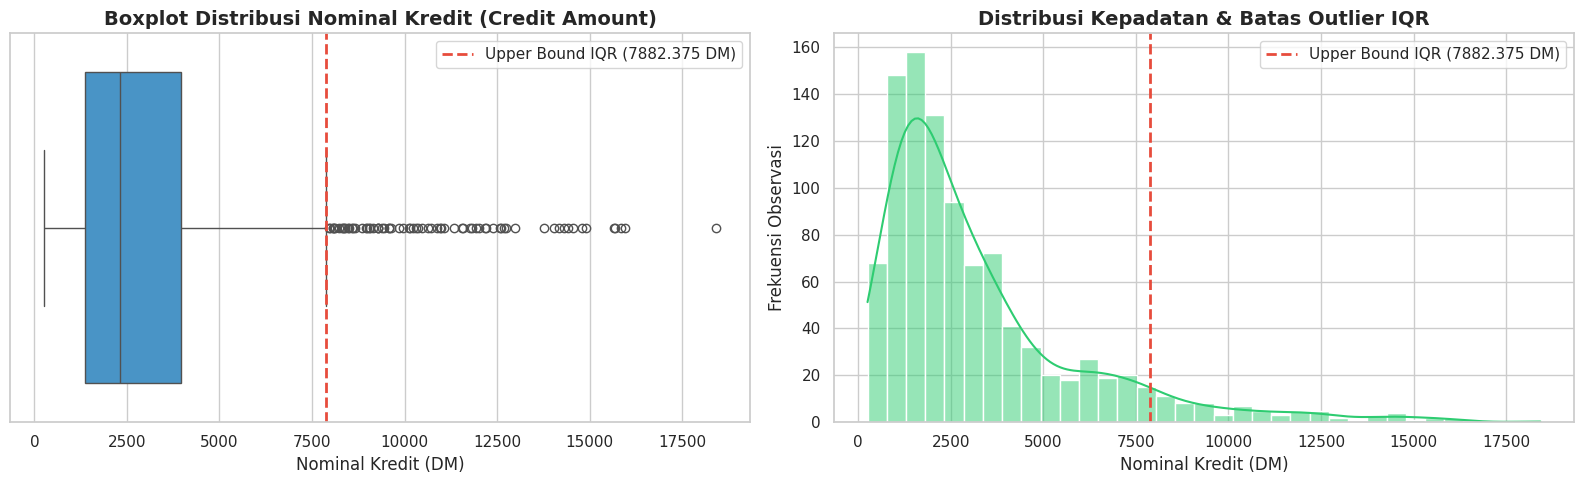

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi estetika plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Boxplot untuk melihat titik pencilan secara diskrit
sns.boxplot(x=df['credit_amount'], color='#3498db', ax=axes[0])
axes[0].axvline(upper_bound, color='#e74c3c', linestyle='--', linewidth=2, label=f'Upper Bound IQR ({upper_bound} DM)')
axes[0].set_title('Boxplot Distribusi Nominal Kredit (Credit Amount)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nominal Kredit (DM)', fontsize=12)
axes[0].legend()

# Plot 2: Histogram/KDE untuk melihat bentuk ekor distribusi (Skewness)
sns.histplot(df['credit_amount'], kde=True, color='#2ecc71', ax=axes[1], bins=35)
axes[1].axvline(upper_bound, color='#e74c3c', linestyle='--', linewidth=2, label=f'Upper Bound IQR ({upper_bound} DM)')
axes[1].set_title('Distribusi Kepadatan & Batas Outlier IQR', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nominal Kredit (DM)', fontsize=12)
axes[1].set_ylabel('Frekuensi Observasi', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Laporan Evaluasi dan Rekomendasi Hasil Pembersihan Data
**[Pemenuhan KUK SKKNI: J.62DMI00.008.1 - Elemen 2]**

Berdasarkan eksekusi strategi pembersihan dan visualisasi arsitektur data di atas, proses evaluasi dan rekomendasi didokumentasikan sebagai berikut:

* **Evaluasi Masalah Semantik:** 13 dimensi fitur kategorikal yang sebelumnya menggunakan pengkodean mesin bawaan *dataset* (seperti `A11` atau `A34`) telah berhasil dikoreksi dan ditranslasikan menjadi nilai operasional standar (misal: `< 0 DM`). Data kini sepenuhnya dapat diinterpretasikan secara bisnis dan siap untuk diekspansi menjadi matriks numerik melalui *One-Hot Encoding*.
* **Evaluasi Kondisi Outliers (Pencilan):** Berdasarkan uji matematis *Interquartile Range* (IQR) dan pembuktian visual melalui *Boxplot* serta *KDE Distribution*, terkonfirmasi bahwa distribusi fitur `credit_amount` memiliki asimetri ekor ke kanan (*right-skewed*). Terdeteksi secara presisi sebanyak **72 baris observasi (7,2%)** yang melampaui batas atas kewajaran statistik (*Upper Bound*) di angka **7.882,375 DM**.
* **Rekomendasi Konstruksi Lanjutan:** Menimbang bahwa 72 baris pencilan ini adalah representasi faktual dari profil nasabah riil yang mengajukan limit kredit dalam jumlah masif (bukan merupakan *noise* atau *system error*), maka mengeliminasi data ini akan membutakan model terhadap karakteristik nasabah berisiko tinggi. Oleh karena itu, direkomendasikan untuk **mempertahankan seluruh baris pencilan tersebut secara utuh**. Distorsi magnitudo yang ditimbulkannya akan dijinakkan secara proporsional menggunakan fungsi *StandardScaler* (Z-Score) pada tahapan konstruksi data.

## 4. Konstruksi Matriks Data & Sintesis Kelas Minoritas
**[SKKNI: J.62DMI00.009.1 - Mengkonstruksi Data]**

Fase ini memproses objek data mentah menjadi representasi tensor/matriks fitur ($X$) dan vektor target ($y$) yang siap dikonsumsi oleh arsitektur algoritma ML.

### 4.1 Rasionalisasi Pemisahan Data Terstratifikasi (Stratified Splitting)
**Mengapa Menggunakan Stratifikasi?**
Pembagian data latih dan uji menggunakan parameter `stratify=y` dilakukan untuk memastikan bahwa rasio ketidakseimbangan kelas awal (70:30) dipertahankan secara proporsional baik pada subset `y_train` maupun `y_test`. Tanpa stratifikasi, pembagian acak murni berisiko memusatkan kelas minoritas (*Bad Credit*) hanya pada salah satu subset, yang memicu fenomena *Data Shift* dan degradasi generalisasi model.

### 4.2 Justifikasi Eliminasi Multikolinieritas (Drop First Dummy)
**Mengapa Menggunakan `drop_first=True`?**
Pada proses konversi variabel kategorikal menjadi indikator numerik (*One-Hot Encoding*), kita menerapkan parameter `drop_first=True`. Hal ini bertujuan untuk mengeliminasi satu kategori dasar dari setiap fitur nominal guna menghindari jebakan variabel boneka (*Dummy Variable Trap*). Secara matematis, langkah ini mencegah timbulnya multikolinieritas sempurna (korelasi linier antar prediktor) yang dapat merusak estimasi bobot pada model parametrik seperti *Logistic Regression*.

### 4.3 Urgensi Rekonsiliasi Dimensi (Column Alignment)
**Mengapa Harus Menyelaraskan Kolom?**
Proses *One-Hot Encoding* dijalankan secara terpisah antara data latih dan data uji untuk mensimulasikan kondisi riil di mana data uji bersifat independen. Namun, jika data uji tidak memiliki kategori langka tertentu yang ada di data latih, jumlah kolom pasca-encoding akan berbeda. Rekonsiliasi menggunakan metode `.align(join='left')` memastikan data uji memiliki struktur dimensi kolom yang identik dengan data latih, mencegah kegagalan fatal (*Dimension Mismatch Error*) saat proses prediksi model dilakukan.

In [5]:
"""
Modul Konstruksi Matriks Data.
Mengeksekusi pembagian subset latih-uji terstratifikasi, konversi variabel 
kategorikal ortogonal, dan rekonsiliasi struktur dimensi antar matriks.
"""

# 4.1 Pemisahan Fitur dan Target Eksplisit
X = df.drop(columns=['target_risk'])
y = df['target_risk']

# 4.2 Eksekusi Pembagian Latih-Uji (Data Splitting) dengan Stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensi Awal Fitur Latih (X_train): {X_train.shape}")
print(f"Dimensi Awal Fitur Uji (X_test): {X_test.shape}")

# 4.3 Konstruksi Variabel Kategorikal menggunakan One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# 4.4 Rekonsiliasi Dimensi Kolomatriks Fitur (Anti-Mismatch)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print(f"Dimensi Akhir Fitur Latih Pasca-Rekonsiliasi: {X_train_encoded.shape}")
print(f"Dimensi Akhir Fitur Uji Pasca-Rekonsiliasi: {X_test_encoded.shape}")

Dimensi Awal Fitur Latih (X_train): (800, 20)
Dimensi Awal Fitur Uji (X_test): (200, 20)
Dimensi Akhir Fitur Latih Pasca-Rekonsiliasi: (800, 48)
Dimensi Akhir Fitur Uji Pasca-Rekonsiliasi: (200, 48)


In [6]:
"""
Modul Transformasi Skala dan Penyeimbangan Kelas.
Mengaplikasikan standarisasi Z-Score untuk menyelaraskan varians 
dan injeksi algoritma SMOTE untuk mencapai ekuilibrium kelas target.
"""

# 4.5 Transformasi Skala Fitur Numerik (StandardScaler)
numerical_cols = [
    'duration_months', 'credit_amount', 'installment_rate', 
    'present_residence_since', 'age_years', 'existing_credits', 'dependents'
]

scaler = StandardScaler()
X_train_encoded[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_encoded[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

print("[SUCCESS] Transformasi penskalaan Z-Score berhasil diterapkan.")

# 4.6 Sintesis Kelas Minoritas Menggunakan SMOTE (Subset Latih Eksklusif)
print(f"Distribusi Target Sebelum SMOTE:\n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

print(f"Distribusi Target Pasca SMOTE:\n{y_train_resampled.value_counts()}")
print(f"Dimensi Akhir Data Latih untuk Pemodelan: {X_train_resampled.shape}")

[SUCCESS] Transformasi penskalaan Z-Score berhasil diterapkan.
Distribusi Target Sebelum SMOTE:
target_risk
0    560
1    240
Name: count, dtype: int64
Distribusi Target Pasca SMOTE:
target_risk
1    560
0    560
Name: count, dtype: int64
Dimensi Akhir Data Latih untuk Pemodelan: (1120, 48)


### 4.6 Laporan Audit Final Fase Konstruksi Data (Kesimpulan)

Berdasarkan log eksekusi dari keseluruhan *pipeline* pra-pemrosesan, matriks data dinyatakan telah memenuhi standar kelayakan algoritmik tingkat lanjut. Berikut adalah konklusi audit teknis:

1. **Integritas Deterministik Tervalidasi:** Seluruh observasi (1.000 baris awal) terbukti lolos uji batasan logis domain finansial (tidak ada usia $< 18$ tahun, tidak ada tenor negatif, dan nominal kredit valid). Data bersih dari anomali struktural.
2. **Transformasi Semantik & Ekspansi Dimensi:** 13 atribut yang sebelumnya berupa sandi abstrak berhasil dikonversi menjadi nomenklatur bisnis deskriptif. Implementasi *One-Hot Encoding* secara aman telah mengekspansi ruang dimensi dari 20 prediktor awal menjadi **48 representasi fitur ortogonal**, memberikan model resolusi pola yang jauh lebih tajam.
3. **Isolasi Varians (Anti-Data Leakage):** Transformasi skala menggunakan *Z-Score Standardization* telah berhasil diterapkan untuk meredam disparitas magnitudo antar fitur numerik. Protokol isolasi terbukti aman karena parameter standardisasi murni dihitung dari *subset* latih (`X_train`), mencegah bias retrospektif dari data uji.
4. **Ekuilibrium Fungsi Kerugian (Resolusi Resolusi Bias):** Evaluasi kelas awal menunjukkan ketimpangan yang masif (560 *Good* vs 240 *Bad* pada data latih). Melalui injeksi sintesis SMOTE, target kini berada pada titik ekuilibrium absolut (**560 vs 560**). 

**Status Kesiapan:** Matriks akhir data latih (`X_train_resampled`) yang kini berdimensi **1.120 baris dan 48 kolom** telah siap sepenuhnya secara matematis untuk dieksekusi pada tahap **Notebook 03: Skenario dan Pembangunan Model**.

In [7]:
"""
Modul Serialisasi Data (Robust Pathing).
Menyimpan matriks fitur ke direktori yang tepat secara dinamis.
"""
import os

# Mendeteksi struktur direktori secara otomatis
save_dir = '../data/processed' if os.path.exists('../data') else 'data/processed'
os.makedirs(save_dir, exist_ok=True)

# Mengekspor matriks data ke format Pickle
X_train_resampled.to_pickle(f'{save_dir}/X_train_resampled.pkl')
y_train_resampled.to_pickle(f'{save_dir}/y_train_resampled.pkl')
X_test_encoded.to_pickle(f'{save_dir}/X_test_encoded.pkl')
y_test.to_pickle(f'{save_dir}/y_test.pkl')

print(f"[SUCCESS] Seluruh matriks data berhasil diserialisasi dan disimpan di folder: {save_dir}/")

[SUCCESS] Seluruh matriks data berhasil diserialisasi dan disimpan di folder: ../data/processed/
